# Path Patching Results
Load saved tensors from `results/` and compare the 2B and 12B heatmaps.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from pathlib import Path

VISUALS_DIR = Path("results/visuals")
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Gemma 2B
resid_2b = torch.load("results/gemma_2b/path_patch_final_resid.pt", 
                       map_location="cpu").numpy()
with open("results/gemma_2b/baseline_metrics.json") as f:
    baseline_2b = json.load(f)

# Gemma 12B
resid_12b = torch.load("results/gemma_12b/path_patch_final_resid.pt",
                        map_location="cpu").numpy()
with open("results/gemma_12b/baseline_metrics.json") as f:
    baseline_12b = json.load(f)

print(f"2B tensor shape: {resid_2b.shape}")
print(f"12B tensor shape: {resid_12b.shape}")
print(f"2B clean_ld={baseline_2b['clean_ld']:.4f}, corrupt_ld={baseline_2b['corrupt_ld']:.4f}")
print(f"12B clean_ld={baseline_12b['clean_ld']:.4f}, corrupt_ld={baseline_12b['corrupt_ld']:.4f}")

2B tensor shape: (18, 8)
12B tensor shape: (48, 16)
2B clean_ld=0.0115, corrupt_ld=-0.6914
12B clean_ld=0.2227, corrupt_ld=-0.0903


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_35983/3554640662.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


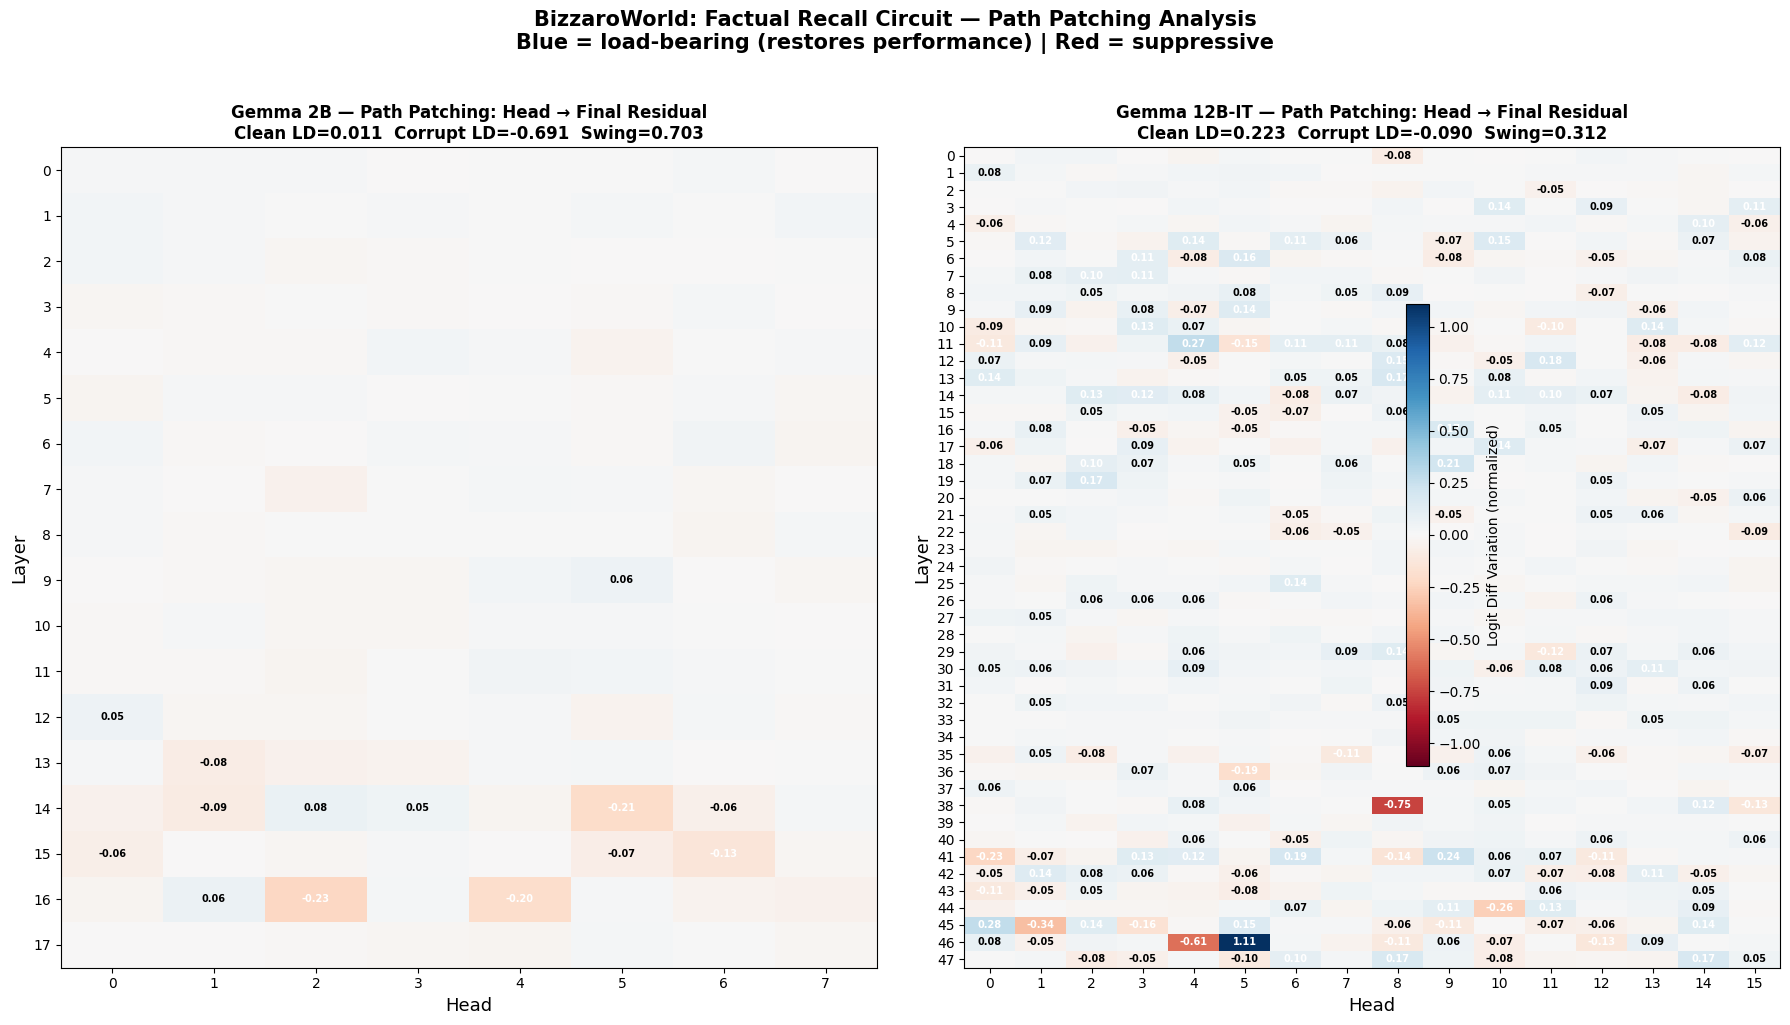

Saved side-by-side heatmap


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Shared colorscale across both models for fair comparison
vmax = max(abs(resid_2b).max(), abs(resid_12b).max())
vmin = -vmax

for ax, tensor, title, baseline in zip(
    axes,
    [resid_2b, resid_12b],
    ["Gemma 2B — Path Patching: Head → Final Residual",
     "Gemma 12B-IT — Path Patching: Head → Final Residual"],
    [baseline_2b, baseline_12b]
):
    im = ax.imshow(tensor, cmap="RdBu", vmin=vmin, vmax=vmax, 
                   aspect="auto", interpolation="nearest")
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(range(tensor.shape[1]))
    ax.set_yticks(range(tensor.shape[0]))
    
    # Annotate cells with values for top candidates
    threshold = 0.05
    for i in range(tensor.shape[0]):
        for j in range(tensor.shape[1]):
            val = tensor[i, j]
            if abs(val) > threshold:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                       fontsize=7, color="white" if abs(val) > 0.1 else "black",
                       fontweight="bold")
    
    subtitle = (f"Clean LD={baseline['clean_ld']:.3f}  "
                f"Corrupt LD={baseline['corrupt_ld']:.3f}  "
                f"Swing={baseline['total_swing']:.3f}")
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")

plt.colorbar(im, ax=axes, label="Logit Diff Variation (normalized)", 
             shrink=0.6, pad=0.02)
plt.suptitle("BizzaroWorld: Factual Recall Circuit — Path Patching Analysis\n"
             "Blue = load-bearing (restores performance) | Red = suppressive",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "path_patch_heatmap_side_by_side.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved side-by-side heatmap")

In [4]:
def get_top_heads(tensor, model_name, n=5):
    flat = tensor.flatten()
    top_neg_idx = np.argsort(flat)[:n]
    top_pos_idx = np.argsort(flat)[-n:][::-1]
    
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    
    print(f"\nTop LOAD-BEARING heads (blue, negative — write correct answer):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    load_bearing = []
    for idx in top_neg_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
        load_bearing.append((int(layer), int(head), float(score)))
    
    print(f"\nTop SUPPRESSIVE heads (red, positive — suppress wrong answer):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    suppressive = []
    for idx in top_pos_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
        suppressive.append((int(layer), int(head), float(score)))
    
    return load_bearing, suppressive

load_bearing_2b, suppressive_2b = get_top_heads(resid_2b, "Gemma 2B", n=5)
load_bearing_12b, suppressive_12b = get_top_heads(resid_12b, "Gemma 12B-IT", n=5)


Gemma 2B

Top LOAD-BEARING heads (blue, negative — write correct answer):
 Layer   Head      Score
--------------------------
    16      2    -0.2305
    14      5    -0.2051
    16      4    -0.1973
    15      6    -0.1318
    14      1    -0.0903

Top SUPPRESSIVE heads (red, positive — suppress wrong answer):
 Layer   Head      Score
--------------------------
    14      2     0.0752
    16      1     0.0640
     9      5     0.0583
    12      0     0.0527
    14      3     0.0518

Gemma 12B-IT

Top LOAD-BEARING heads (blue, negative — write correct answer):
 Layer   Head      Score
--------------------------
    38      8    -0.7461
    46      4    -0.6133
    45      1    -0.3379
    44     10    -0.2617
    41      0    -0.2314

Top SUPPRESSIVE heads (red, positive — suppress wrong answer):
 Layer   Head      Score
--------------------------
    46      5     1.1094
    45      0     0.2754
    11      4     0.2695
    41      9     0.2373
    18      9     0.2061


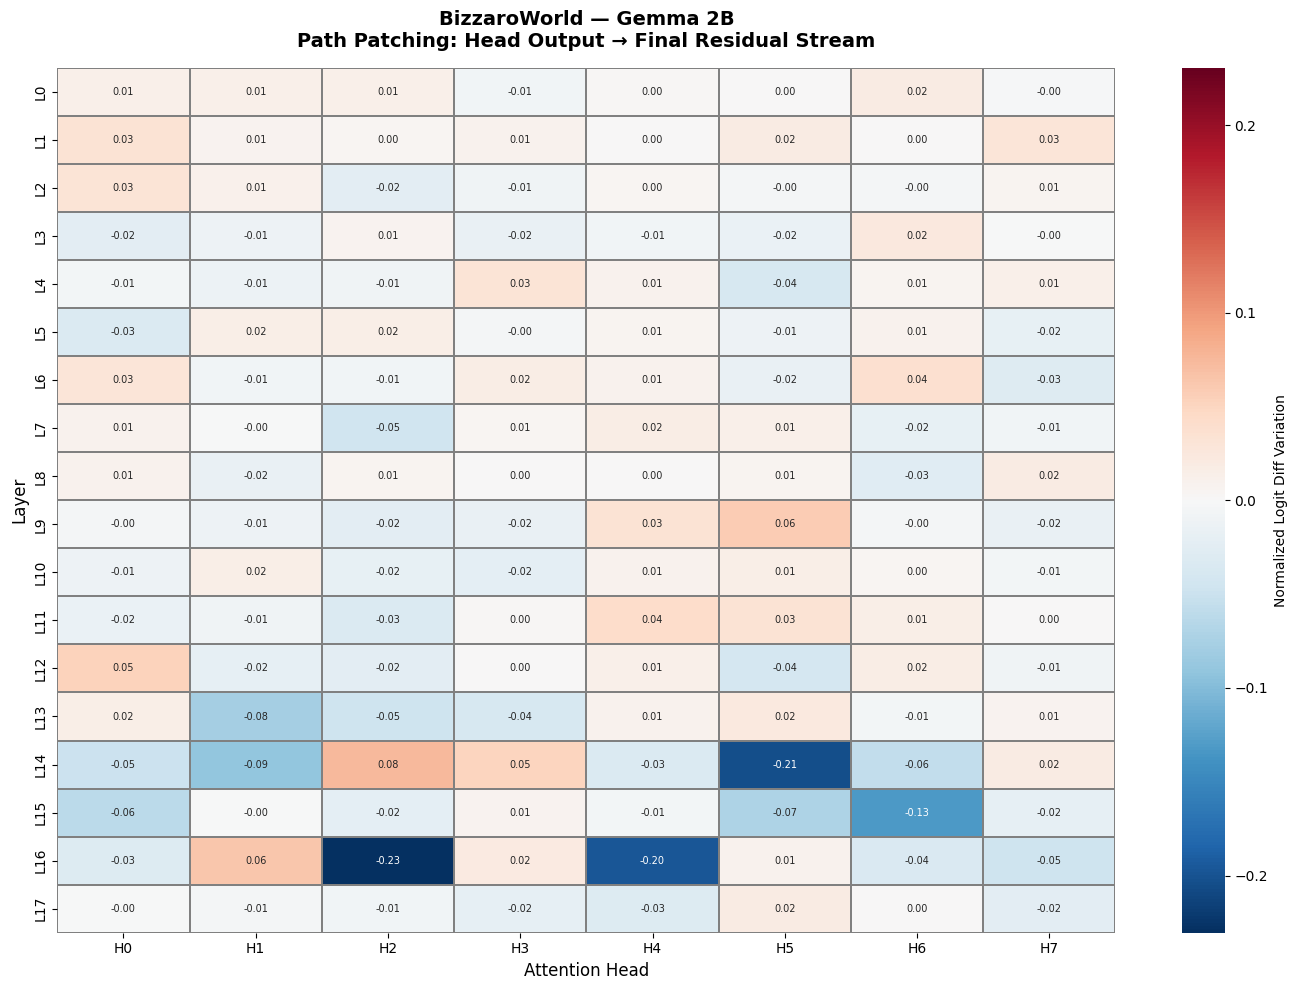

Saved heatmap_2b.png


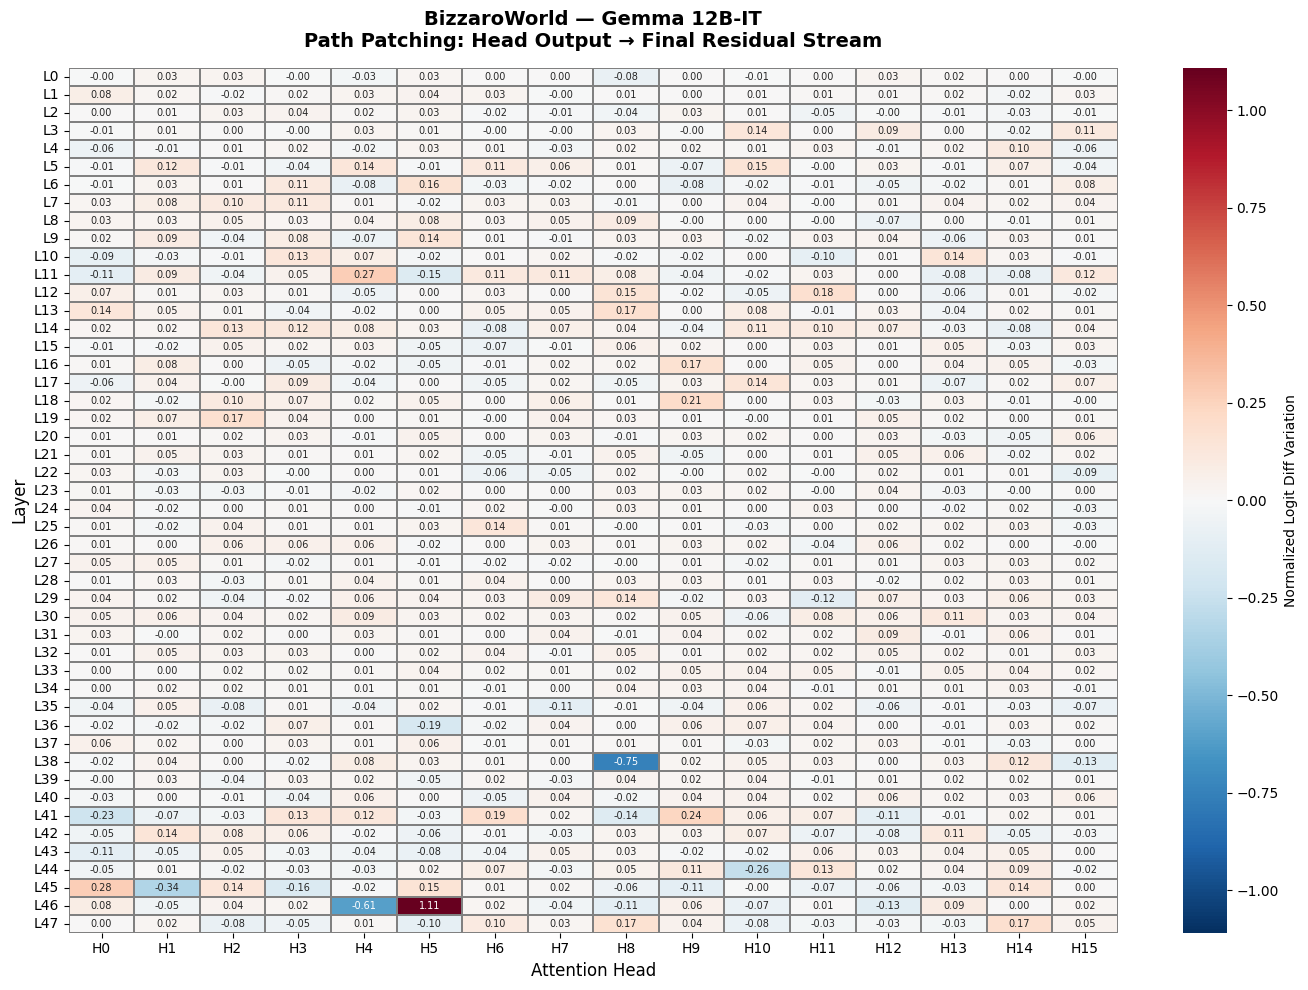

Saved heatmap_12b.png


In [5]:
for tensor, model_name, filename in [
    (resid_2b, "Gemma 2B", "heatmap_2b.png"),
    (resid_12b, "Gemma 12B-IT", "heatmap_12b.png"),
]:
    fig, ax = plt.subplots(figsize=(14, 10))
    vmax = abs(tensor).max()
    
    sns.heatmap(
        tensor,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=tensor.shape[1] <= 16,  # annotate if not too many heads
        fmt=".2f",
        annot_kws={"size": 7},
        xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
        yticklabels=[f"L{i}" for i in range(tensor.shape[0])],
        linewidths=0.3,
        linecolor="gray",
        cbar_kws={"label": "Normalized Logit Diff Variation"}
    )
    
    ax.set_title(f"BizzaroWorld — {model_name}\nPath Patching: Head Output → Final Residual Stream",
                fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Attention Head", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

In [6]:
# Combine load-bearing and suppressive for receiver head patching
# Both are mechanistically important — blue writes correct, red suppresses wrong

receiver_2b_combined = (
    [(l, h) for l, h, s in load_bearing_2b] +
    [(l, h) for l, h, s in suppressive_2b]
)

receiver_12b_combined = (
    [(l, h) for l, h, s in load_bearing_12b] +
    [(l, h) for l, h, s in suppressive_12b]
)

# Deduplicate while preserving order
def deduplicate(lst):
    seen = set()
    result = []
    for item in lst:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result

receiver_2b_combined = deduplicate(receiver_2b_combined)
receiver_12b_combined = deduplicate(receiver_12b_combined)

print("="*60)
print("NEXT RUN COMMANDS (load-bearing + suppressive heads):")
print()
print("Gemma 2B:")
print(f"  Load-bearing: {[(l,h) for l,h,s in load_bearing_2b]}")
print(f"  Suppressive:  {[(l,h) for l,h,s in suppressive_2b]}")
receiver_str_2b = " ".join([f"{l}:{h}" for l, h in receiver_2b_combined])
print(f"\n  CLI (q): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input q")
print(f"  CLI (k): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input k")
print(f"  CLI (v): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input v")

print()
print("Gemma 12B:")
print(f"  Load-bearing: {[(l,h) for l,h,s in load_bearing_12b]}")
print(f"  Suppressive:  {[(l,h) for l,h,s in suppressive_12b]}")
receiver_str_12b = " ".join([f"{l}:{h}" for l, h in receiver_12b_combined])
print(f"\n  CLI (q): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input q")
print(f"  CLI (k): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input k")
print(f"  CLI (v): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input v")

# Save updated receiver heads JSON
with open(VISUALS_DIR / "receiver_heads.json", "w") as f:
    json.dump({
        "gemma_2b": {
            "load_bearing": [(l, h) for l, h, s in load_bearing_2b],
            "suppressive": [(l, h) for l, h, s in suppressive_2b],
            "combined": receiver_2b_combined,
            "scores": {
                "load_bearing": {f"{l},{h}": s for l, h, s in load_bearing_2b},
                "suppressive": {f"{l},{h}": s for l, h, s in suppressive_2b},
            }
        },
        "gemma_12b": {
            "load_bearing": [(l, h) for l, h, s in load_bearing_12b],
            "suppressive": [(l, h) for l, h, s in suppressive_12b],
            "combined": receiver_12b_combined,
            "scores": {
                "load_bearing": {f"{l},{h}": s for l, h, s in load_bearing_12b},
                "suppressive": {f"{l},{h}": s for l, h, s in suppressive_12b},
            }
        }
    }, f, indent=2)

print(f"\nSaved updated receiver_heads.json to {VISUALS_DIR}")

NEXT RUN COMMANDS (load-bearing + suppressive heads):

Gemma 2B:
  Load-bearing: [(16, 2), (14, 5), (16, 4), (15, 6), (14, 1)]
  Suppressive:  [(14, 2), (16, 1), (9, 5), (12, 0), (14, 3)]

  CLI (q): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input q
  CLI (k): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input k
  CLI (v): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input v

Gemma 12B:
  Load-bearing: [(38, 8), (46, 4), (45, 1), (44, 10), (41, 0)]
  Suppressive:  [(46, 5), (45, 0), (11, 4), (41, 9), (18, 9)]

  CLI (q): python run_experiments.py --model gemma_12b --receiver-heads 38:8 46:4 45:1 44:10 41:0 46:5 45:0 11:4 41:9 18:9 --receiver-input q
  CLI (k): python run_experiments.py --model gemma_12b --receiver-heads 38:8 46:4 45:1 44:10 41:0 46:5 45:0 11:4 4

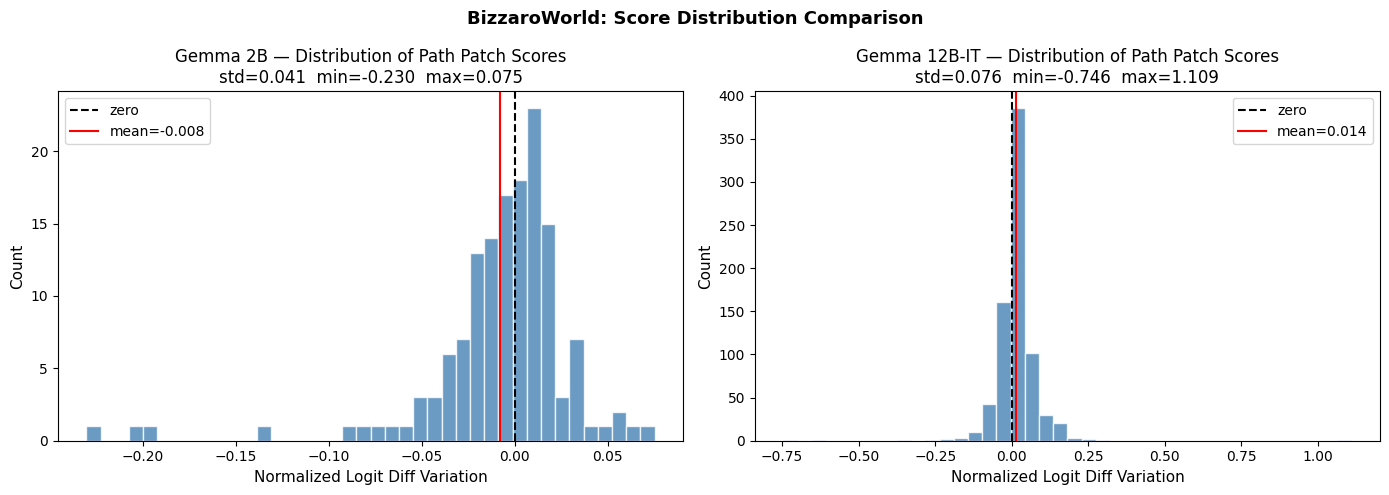

Saved score distributions


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tensor, model_name in [
    (axes[0], resid_2b, "Gemma 2B"),
    (axes[1], resid_12b, "Gemma 12B-IT"),
]:
    flat = tensor.flatten()
    ax.hist(flat, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="zero")
    ax.axvline(flat.mean(), color="red", linestyle="-", linewidth=1.5, 
               label=f"mean={flat.mean():.3f}")
    ax.set_xlabel("Normalized Logit Diff Variation", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{model_name} — Distribution of Path Patch Scores\n"
                 f"std={flat.std():.3f}  min={flat.min():.3f}  max={flat.max():.3f}",
                 fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle("BizzaroWorld: Score Distribution Comparison", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved score distributions")

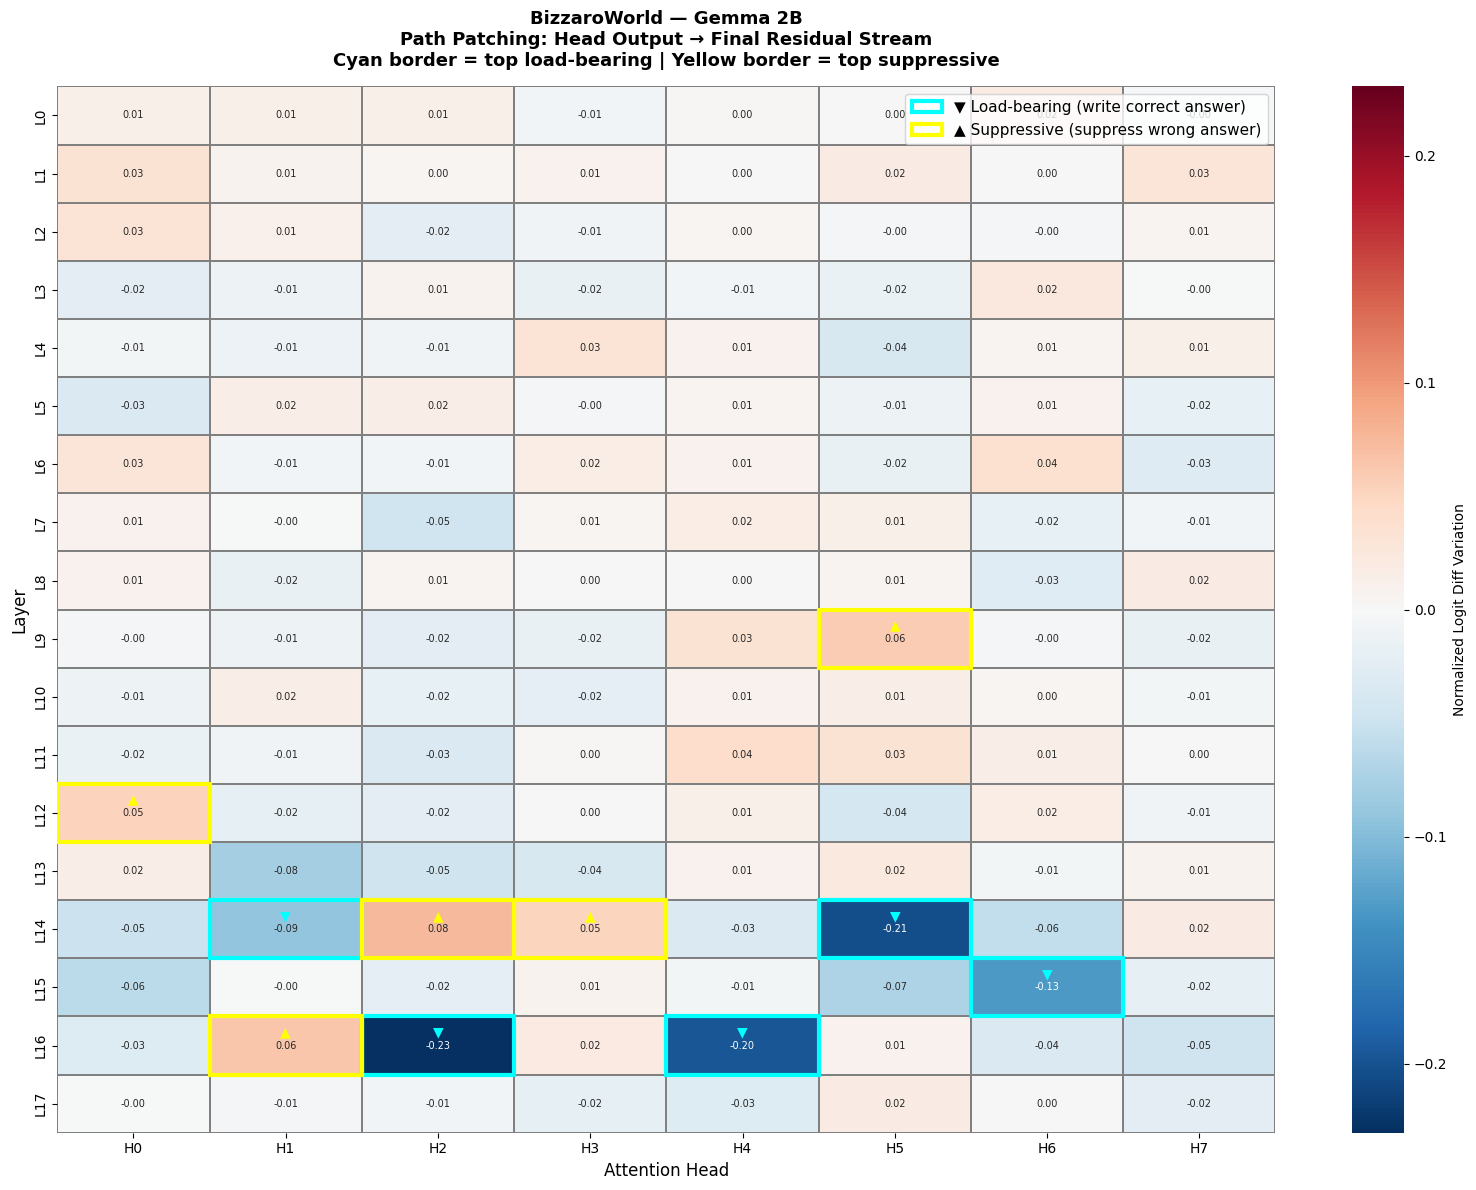

Saved heatmap_2b_annotated.png


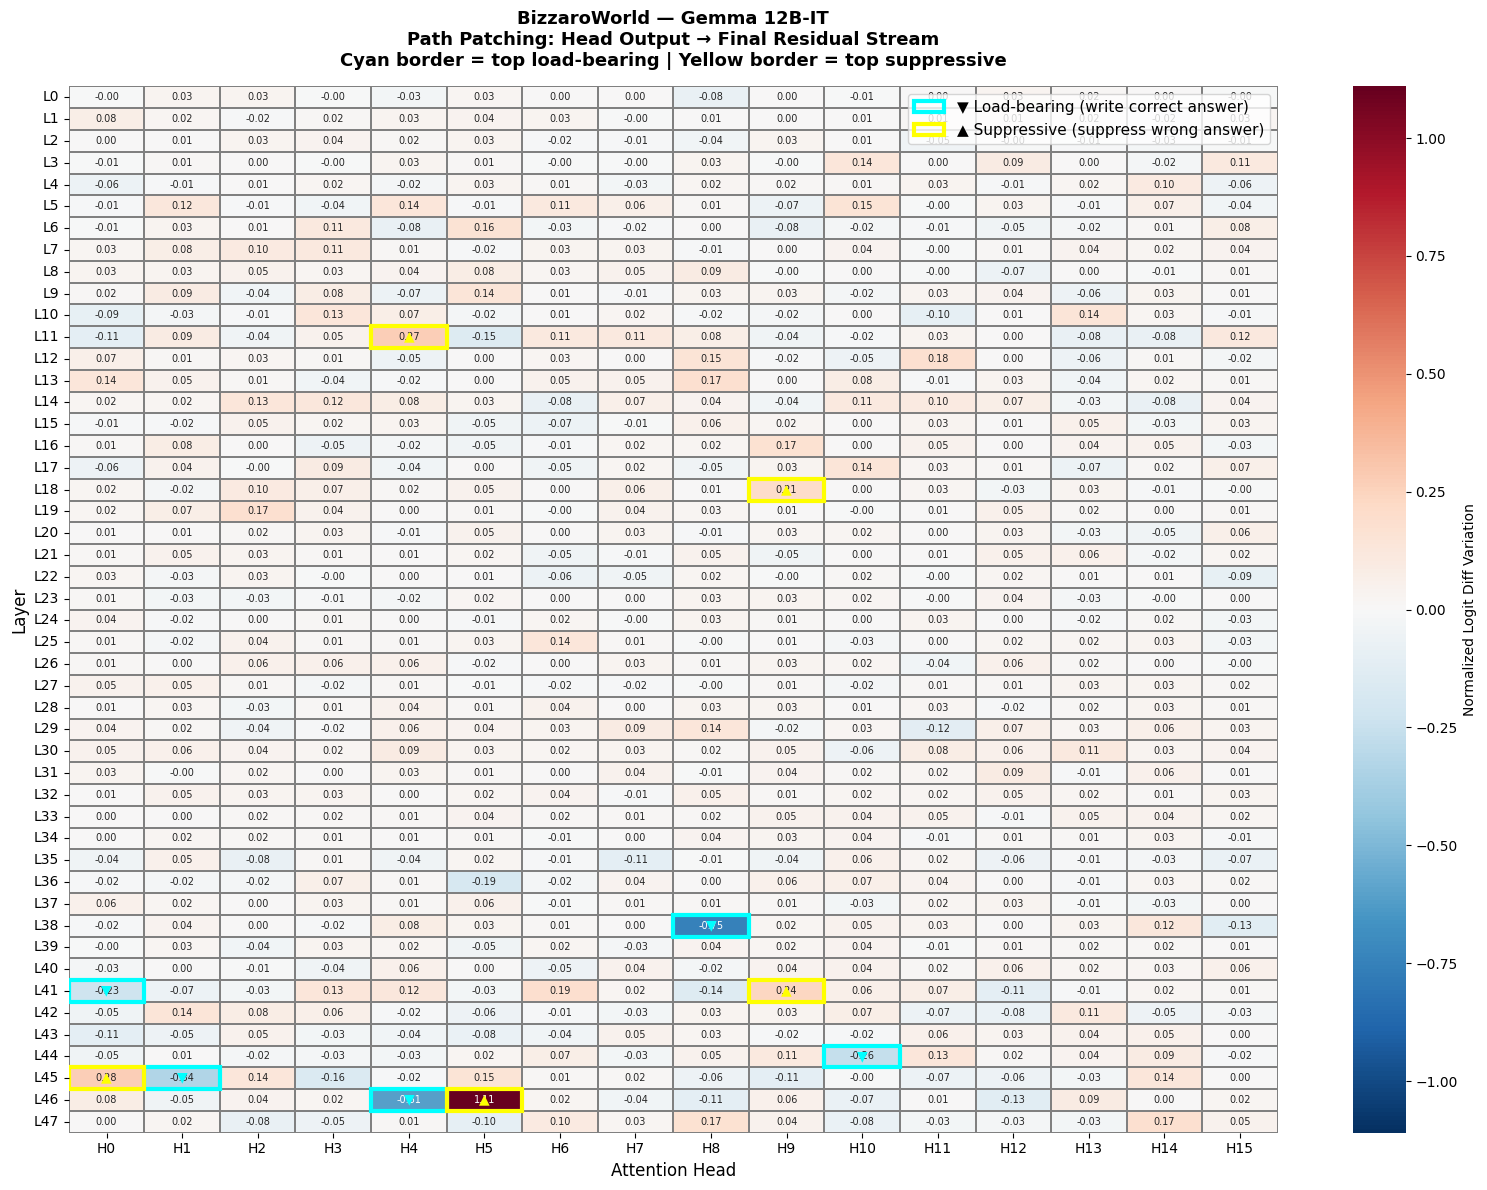

Saved heatmap_12b_annotated.png


In [8]:
# Highlight top blue AND red cells explicitly with markers
for tensor, model_name, filename, lb, sup in [
    (resid_2b, "Gemma 2B", "heatmap_2b_annotated.png", 
     load_bearing_2b, suppressive_2b),
    (resid_12b, "Gemma 12B-IT", "heatmap_12b_annotated.png",
     load_bearing_12b, suppressive_12b),
]:
    fig, ax = plt.subplots(figsize=(16, 12))
    vmax = abs(tensor).max()
    
    sns.heatmap(
        tensor, ax=ax, cmap="RdBu_r", center=0,
        vmin=-vmax, vmax=vmax,
        annot=tensor.shape[1] <= 16,
        fmt=".2f", annot_kws={"size": 7},
        xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
        yticklabels=[f"L{i}" for i in range(tensor.shape[0])],
        linewidths=0.3, linecolor="gray",
        cbar_kws={"label": "Normalized Logit Diff Variation"}
    )
    
    # Mark load-bearing heads with blue star
    for l, h, s in lb:
        ax.add_patch(plt.Rectangle((h, l), 1, 1, 
                     fill=False, edgecolor="cyan", lw=3))
        ax.text(h + 0.5, l + 0.15, "▼", ha="center", va="top",
               fontsize=10, color="cyan", fontweight="bold")
    
    # Mark suppressive heads with red star  
    for l, h, s in sup:
        ax.add_patch(plt.Rectangle((h, l), 1, 1,
                     fill=False, edgecolor="yellow", lw=3))
        ax.text(h + 0.5, l + 0.15, "▲", ha="center", va="top",
               fontsize=10, color="yellow", fontweight="bold")
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="none", edgecolor="cyan", linewidth=3,
              label="▼ Load-bearing (write correct answer)"),
        Patch(facecolor="none", edgecolor="yellow", linewidth=3,
              label="▲ Suppressive (suppress wrong answer)"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", 
              fontsize=11, framealpha=0.8)
    
    ax.set_title(
        f"BizzaroWorld — {model_name}\n"
        f"Path Patching: Head Output → Final Residual Stream\n"
        f"Cyan border = top load-bearing | Yellow border = top suppressive",
        fontsize=13, fontweight="bold", pad=15
    )
    ax.set_xlabel("Attention Head", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")